
<style>
/* ===== Persian markdown text ===== */
.jp-RenderedHTMLCommon,
.text_cell_render,
.jp-MarkdownOutput {
    font-family: Arial, Tahoma, "Noto Sans Arabic", "DejaVu Sans", sans-serif !important;
    font-size: 16px !important;
    line-height: 1.95 !important;
    direction: rtl !important;
    text-align: right !important;
    color: #111 !important;
}

h1 {
    font-size: 32px !important;
    margin-top: 8px !important;
}

h2 {
    font-size: 26px !important;
    margin-top: 24px !important;
}

h3 {
    font-size: 21px !important;
    margin-top: 18px !important;
}

table {
    width: 100% !important;
    font-size: 15px !important;
    direction: rtl !important;
    border-collapse: collapse !important;
}

th, td {
    text-align: right !important;
    padding: 7px !important;
}

/* ===== Code cells: always LTR ===== */
pre,
code,
.CodeMirror,
.cm-editor,
.jp-CodeMirrorEditor,
.jp-InputArea-editor {
    font-family: "DejaVu Sans Mono", Consolas, "Courier New", monospace !important;
    font-size: 14px !important;
    line-height: 1.55 !important;
    direction: ltr !important;
    text-align: left !important;
    unicode-bidi: plaintext !important;
}

/* ===== Callout boxes ===== */
.note-box {
    border: 1px solid #9aa4b2;
    border-radius: 8px;
    padding: 12px 16px;
    margin: 12px 0;
    background: #f8fafc;
}
</style>


<div dir="rtl">

# جلسه ۵ — Classification Methods and Model Evaluation

**Machine Learning with Python**  
**مدت جلسه: ۲ ساعت**

### سؤال اصلی جلسه

> اگر Target به چند Class تبدیل شود، مدل‌ها و معیارهای ارزیابی چگونه تغییر می‌کنند؟

مسیر جلسه:

**Three-Class Target → Baseline → Logistic Regression → KNN → Linear SVM → Kernel SVM → Decision Tree → Random Forest → Metrics → Confusion Matrix → Model Comparison**

</div>

<div dir="rtl">

## اهداف یادگیری

در پایان این جلسه، دانشجو باید بتواند:

- تفاوت Regression و Classification را توضیح دهد؛
- Target عددی را به سه Class تبدیل کند؛
- Logistic Regression، KNN، SVM، Decision Tree و Random Forest را اجرا کند؛
- تفاوت ساده‌ی **Linear SVM** و **Kernel SVM** را بداند؛
- معیارهای `Accuracy`، `Precision`، `Recall` و `F1-score` را تفسیر کند؛
- Confusion Matrix را بخواند؛
- مدل‌ها را روی Validation و Test مقایسه کند.

</div>

<div dir="rtl">

## ۱. از Regression به Classification

در این جلسه همان Diabetes Dataset را نگه می‌داریم، اما Target عددی را به سه Class تبدیل می‌کنیم:

- **Low**
- **Medium**
- **High**

برای جلوگیری از Data Leakage، مرز Classها را فقط با استفاده از `y_train` به‌دست می‌آوریم.

</div>

<div dir="rtl">

### تبدیل Target به سه Class

<div style="text-align:center;">
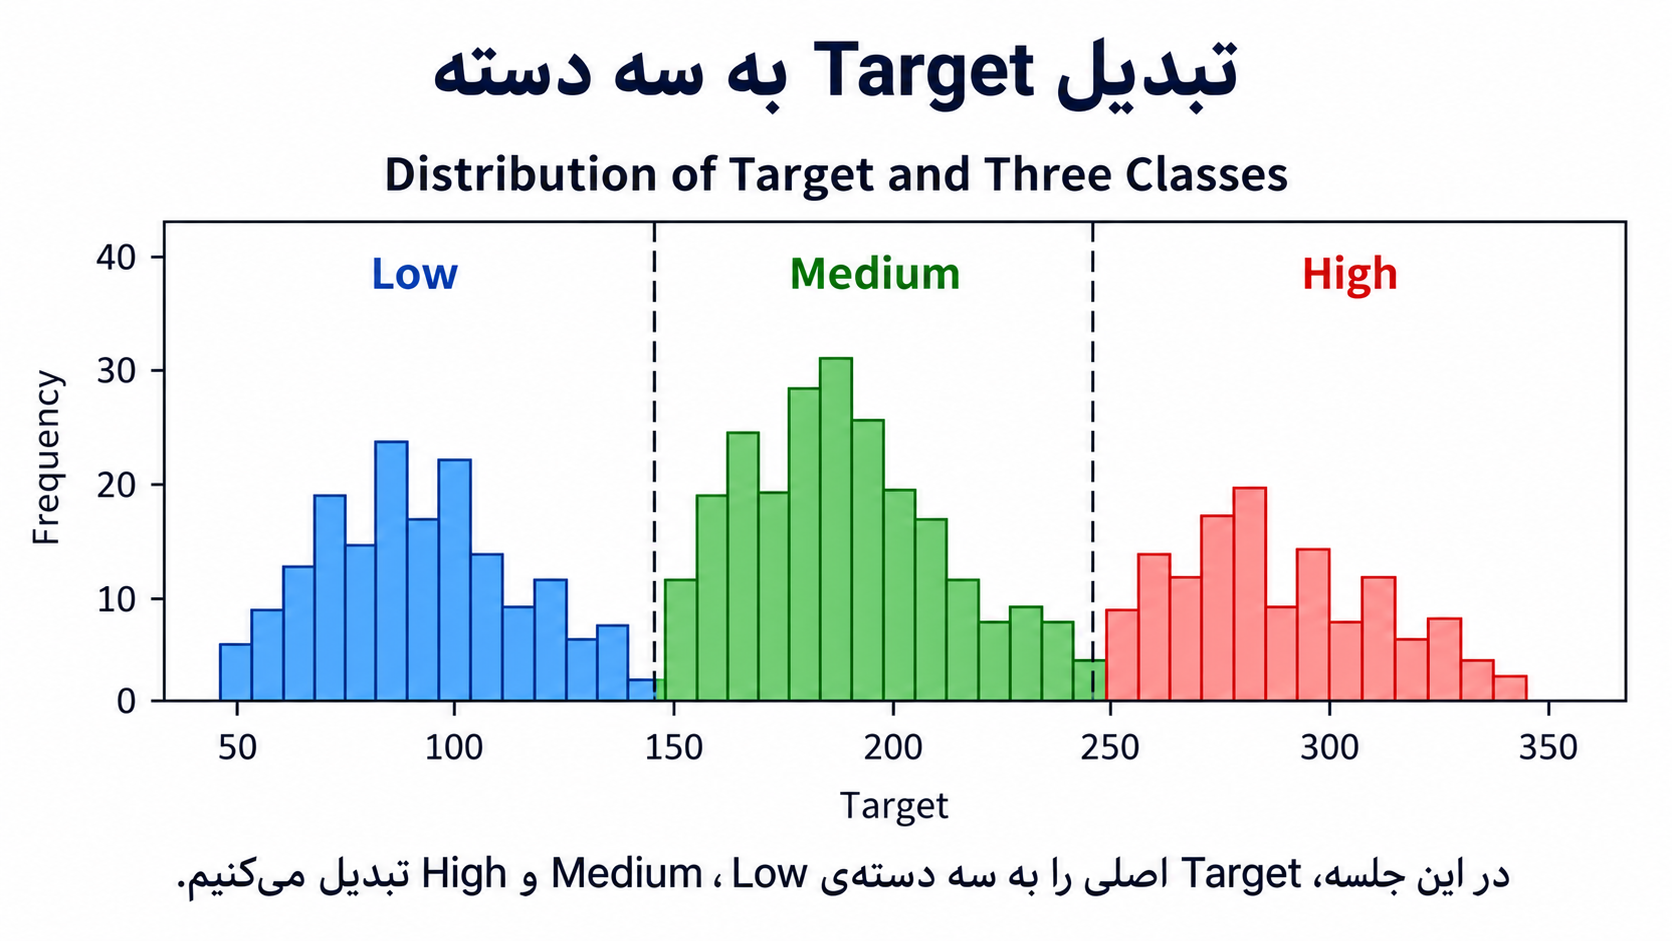
</div>

<p style="text-align:center; font-size:14px;">
در این جلسه، Target اصلی را به سه دسته‌ی <b>Low</b>، <b>Medium</b> و <b>High</b> تبدیل می‌کنیم.
</p>

</div>

In [1]:
from sklearn.datasets import load_diabetes

# Load the diabetes dataset.
data = load_diabetes(as_frame=True, scaled=False)

# Features.
X = data.data

# Numeric target.
y = data.target

print("X shape:", X.shape)
print("y shape:", y.shape)

print("\nFirst 5 rows of X:")
print(X.head())

X shape: (442, 10)
y shape: (442,)

First 5 rows of X:
    age  sex   bmi     bp     s1     s2    s3   s4      s5    s6
0  59.0  2.0  32.1  101.0  157.0   93.2  38.0  4.0  4.8598  87.0
1  48.0  1.0  21.6   87.0  183.0  103.2  70.0  3.0  3.8918  69.0
2  72.0  2.0  30.5   93.0  156.0   93.6  41.0  4.0  4.6728  85.0
3  24.0  1.0  25.3   84.0  198.0  131.4  40.0  5.0  4.8903  89.0
4  50.0  1.0  23.0  101.0  192.0  125.4  52.0  4.0  4.2905  80.0


<div dir="rtl">

## ۲. Train / Validation / Test Split و ساخت Classها

ابتدا داده را به سه بخش Train، Validation و Test تقسیم می‌کنیم.

بعد فقط با استفاده از `y_train` دو Threshold می‌سازیم تا Target به سه Class تبدیل شود.

</div>

In [2]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split

# Use 60% for training and 40% as temporary data.
X_train, X_temp, y_train_number, y_temp_number = train_test_split(
    X,
    y,
    test_size=0.40,
    random_state=0
)

# Calculate class thresholds using the training target only.
low_threshold = y_train_number.quantile(1/3)
high_threshold = y_train_number.quantile(2/3)

print("Low threshold:", round(low_threshold, 2))
print("High threshold:", round(high_threshold, 2))

# Convert the numeric training target into three classes.
y_train = pd.cut(
    y_train_number,
    bins=[-np.inf, low_threshold, high_threshold, np.inf],
    labels=["Low", "Medium", "High"]
)

# Convert the temporary target using the same training thresholds.
y_temp = pd.cut(
    y_temp_number,
    bins=[-np.inf, low_threshold, high_threshold, np.inf],
    labels=["Low", "Medium", "High"]
)

# Split the temporary data into validation and test sets.
X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=0,
    stratify=y_temp
)

print("\nTrain:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)

Low threshold: 94.0
High threshold: 190.0

Train: (265, 10)
Validation: (88, 10)
Test: (89, 10)


In [3]:
# Show the number of training samples in each class.
print("Train class distribution:")
print(y_train.value_counts())

Train class distribution:
target
Medium    89
Low       88
High      88
Name: count, dtype: int64


<div dir="rtl" class="note-box">

### نکته

در اینجا Dataset اصلی برای Regression ساخته شده است، اما ما برای **هدف آموزشی** آن را به یک مسئله‌ی Classification تبدیل کرده‌ایم تا Workflow مربوط به Classification را روی یک Dataset آشنا تمرین کنیم.

</div>

<div dir="rtl">

## ۳. Baseline Model

قبل از مدل‌های اصلی، یک مدل پایه می‌سازیم.

`DummyClassifier(strategy="most_frequent")`

این مدل همیشه پرتکرارترین Class را پیش‌بینی می‌کند.

</div>

In [4]:
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score

# Create the baseline classifier.
baseline = DummyClassifier(
    strategy="most_frequent"
)

# Train the model.
baseline.fit(X_train, y_train)

# Predict the validation data.
pred_baseline = baseline.predict(X_val)

# Calculate accuracy.
baseline_accuracy = accuracy_score(y_val, pred_baseline)

print("Baseline Accuracy:", round(baseline_accuracy, 3))

Baseline Accuracy: 0.466


<div dir="rtl">

## ۴. Logistic Regression

با وجود اسم Regression، این مدل یکی از مدل‌های معروف Classification است.

Logistic Regression برای هر Class یک Probability می‌سازد و سپس Class نهایی را انتخاب می‌کند.

چون این مدل به Scale ویژگی‌ها حساس است، قبل از آن از `StandardScaler` استفاده می‌کنیم.

</div>

<div dir="rtl">

### ایده‌ی Logistic Regression

<div style="text-align:center;">
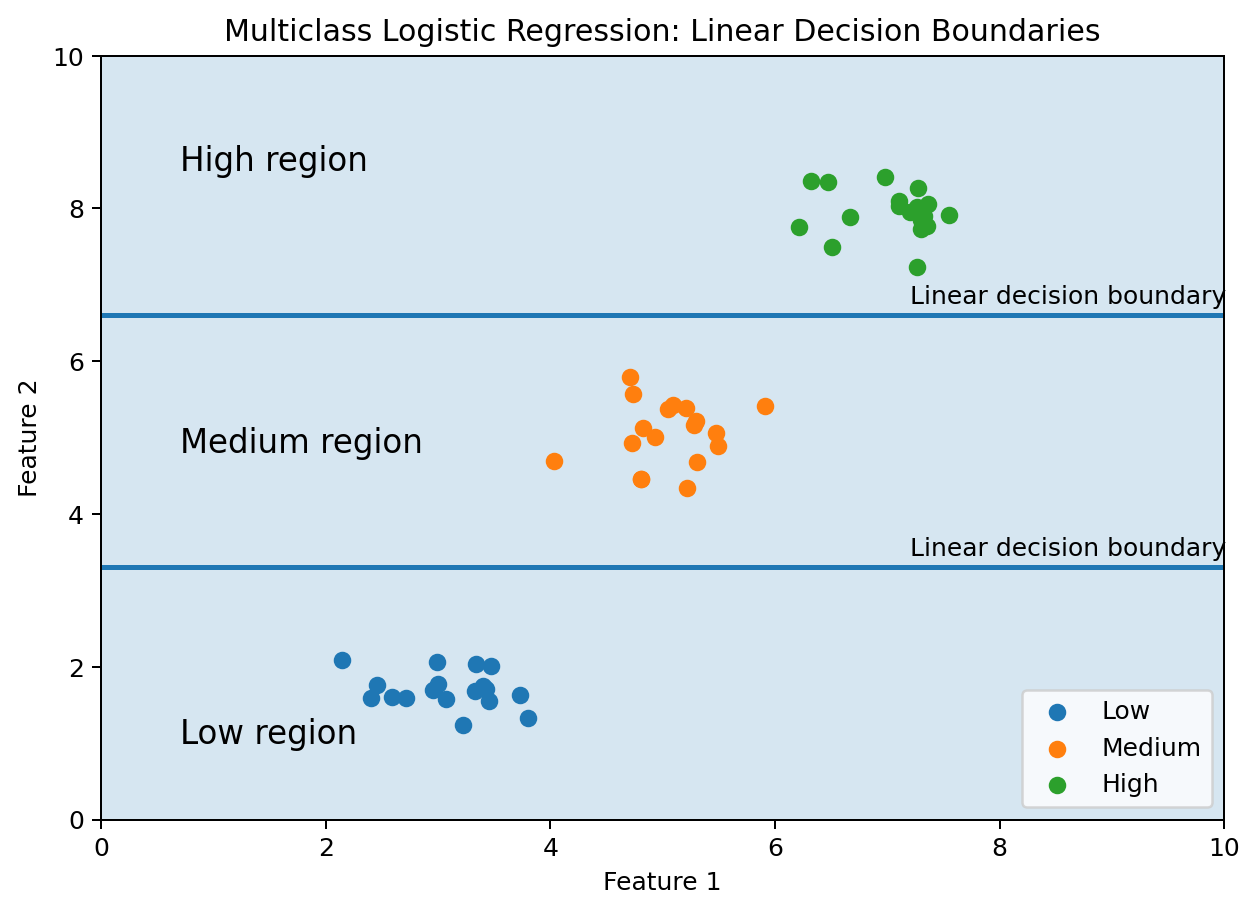
</div>

<div class="note-box">

در Logistic Regression معمولی، اگر از Featureهای اصلی استفاده کنیم، Decision Boundaryها خطی هستند.

در شکل بالا:

- نقاط `Low` داخل ناحیه‌ی Low قرار دارند.
- نقاط `Medium` داخل ناحیه‌ی Medium قرار دارند.
- نقاط `High` داخل ناحیه‌ی High قرار دارند.
- دو خط مستقیم، Decision Boundary بین سه Class را نشان می‌دهند.

در فضای دوبعدی Boundary به شکل خط مستقیم دیده می‌شود؛ در ابعاد بالاتر به آن Hyperplane می‌گوییم.

</div>

</div>

In [5]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# Standardize the features.
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

# Create the Logistic Regression model.
logistic_model = LogisticRegression(
    max_iter=2000
)

# Train the model.
logistic_model.fit(X_train_scaled, y_train)

# Predict the validation data.
pred_logistic = logistic_model.predict(X_val_scaled)

# Calculate accuracy.
logistic_accuracy = accuracy_score(y_val, pred_logistic)

print("Logistic Regression Accuracy:", round(logistic_accuracy, 3))

Logistic Regression Accuracy: 0.545


In [6]:
import pandas as pd

# Get class probabilities for the first five validation samples.
probabilities = logistic_model.predict_proba(
    X_val_scaled[:5]
)

# Display the probability for each class.
probability_table = pd.DataFrame(
    probabilities,
    columns=logistic_model.classes_
)

print(probability_table.round(3))

    High    Low  Medium
0  0.978  0.000   0.021
1  0.177  0.186   0.637
2  0.649  0.044   0.307
3  0.507  0.095   0.398
4  0.655  0.056   0.289


In [ ]:
print("Classes:")
print(logistic_model.classes_)

print("\nCoefficients:")
print(logistic_model.coef_)

print("\nIntercept:")
print(logistic_model.intercept_)

Classes:
['High' 'Low' 'Medium']

Coefficients:
[[-0.19930867 -0.21361772  0.6613467   0.51027489  0.02718807 -0.14997431
  -0.37833286 -0.03607432  0.78821102 -0.01532971]
 [ 0.19801153  0.30410101 -0.58667119 -0.36551326 -0.14174423  0.14163081
   0.60125892  0.29381204 -0.84655517 -0.07015555]
 [ 0.00129714 -0.09048329 -0.07467551 -0.14476163  0.11455616  0.0083435
  -0.22292606 -0.25773771  0.05834415  0.08548526]]

Intercept:
[-0.21278067 -0.23493337  0.44771405]


<div dir="rtl">

## ۵. KNN Classification

KNN در Classification نیز از نزدیک‌ترین Observationها استفاده می‌کند.

اما به‌جای میانگین گرفتن از Target، Class همسایه‌ها را بررسی می‌کند و با رأی اکثریت تصمیم می‌گیرد.

چون KNN بر اساس فاصله کار می‌کند، Scaling مهم است.

</div>

<div dir="rtl">

### ایده‌ی KNN Classification

<div style="text-align:center;">
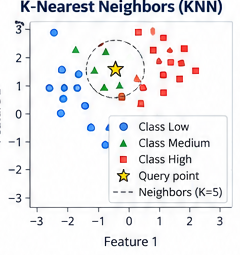
</div>

<p style="text-align:center; font-size:14px;">Class نقطه‌ی جدید با توجه به Class نزدیک‌ترین همسایه‌ها تعیین می‌شود.</p>

</div>

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

# Create the KNN classifier.
knn_model = KNeighborsClassifier(
    n_neighbors=12
)

############### n_neighbors=12, weights="distance"

# Train the model.
knn_model.fit(X_train_scaled, y_train)

# Predict the validation data.
pred_knn = knn_model.predict(X_val_scaled)

# Calculate accuracy.
knn_accuracy = accuracy_score(y_val, pred_knn)

print("KNN Accuracy:", round(knn_accuracy, 3))

KNN Accuracy: 0.557


<div dir="rtl">

## ۶. SVM — ایده‌ی کلی

SVM تلاش می‌کند مرزی پیدا کند که Classها را از هم جدا کند.

نکته‌ی اصلی SVM این است که فقط به جدا شدن کلاس‌ها قانع نیست؛ بلکه مرزی می‌خواهد که **بیشترین Margin** را داشته باشد.

### Support Vector

نقاطی که نزدیک مرز قرار دارند و در تعیین آن نقش مهمی دارند، **Support Vector** نام دارند.

در این جلسه دو نوع SVM را می‌بینیم:

- **Linear SVM**
- **Kernel SVM (RBF)**

چون SVM به Scale حساس است، از همان داده‌های `Scaled` استفاده می‌کنیم.

</div>

<div dir="rtl">

## ۷. Linear SVM

در **Linear SVM**، مرز تصمیم یک خط مستقیم (یا در ابعاد بالاتر یک Hyperplane) است.

این مدل زمانی مناسب‌تر است که جداسازی کلاس‌ها تقریباً خطی باشد.

</div>

<div dir="rtl">

### Linear SVM

<div style="text-align:center;">
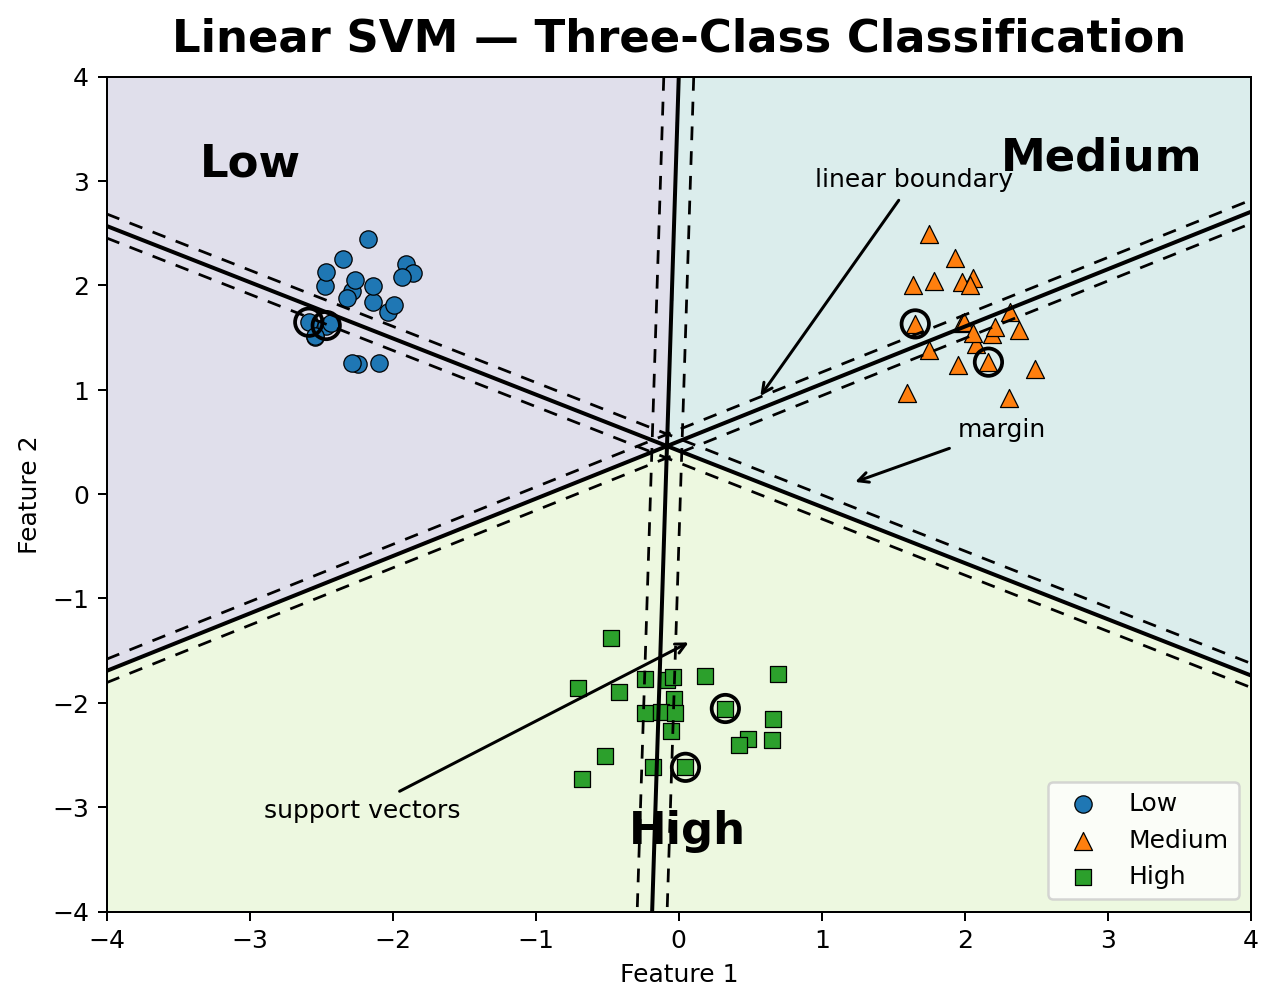
</div>

<p style="text-align:center; font-size:14px;">
در این شکل، ناحیه‌های مربوط به سه Class با <b>مرزهای خطی</b> از هم جدا شده‌اند.
خطوط dashed مفهوم <b>margin</b> را نشان می‌دهند و دایره‌های دور برخی نقاط، نمونه‌ای از <b>support vector</b>ها هستند.
</p>

</div>

In [ ]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

# Create the Linear SVM classifier.
svm_linear_model = SVC(
    kernel="linear",
    C=1
)

###### C=0.5

# Train the model.
svm_linear_model.fit(X_train_scaled, y_train)

# Predict the validation data.
pred_svm_linear = svm_linear_model.predict(X_val_scaled)

# Calculate accuracy.
svm_linear_accuracy = accuracy_score(
    y_val,
    pred_svm_linear
)

print("Linear SVM Accuracy:", round(svm_linear_accuracy, 3))

Linear SVM Accuracy: 0.568


<div dir="rtl">

## ۸. Kernel SVM (RBF)

اگر مرز بین کلاس‌ها غیرخطی باشد، **Kernel SVM** می‌تواند مفیدتر باشد.

در اینجا از Kernel نوع **RBF** استفاده می‌کنیم.

ایده‌ی ساده:

> مدل فضای Featureها را به شکلی بررسی می‌کند که بتواند مرزهای خمیده و غیرخطی بسازد.

</div>

<div dir="rtl">

### Kernel SVM (RBF)

<div style="text-align:center;">
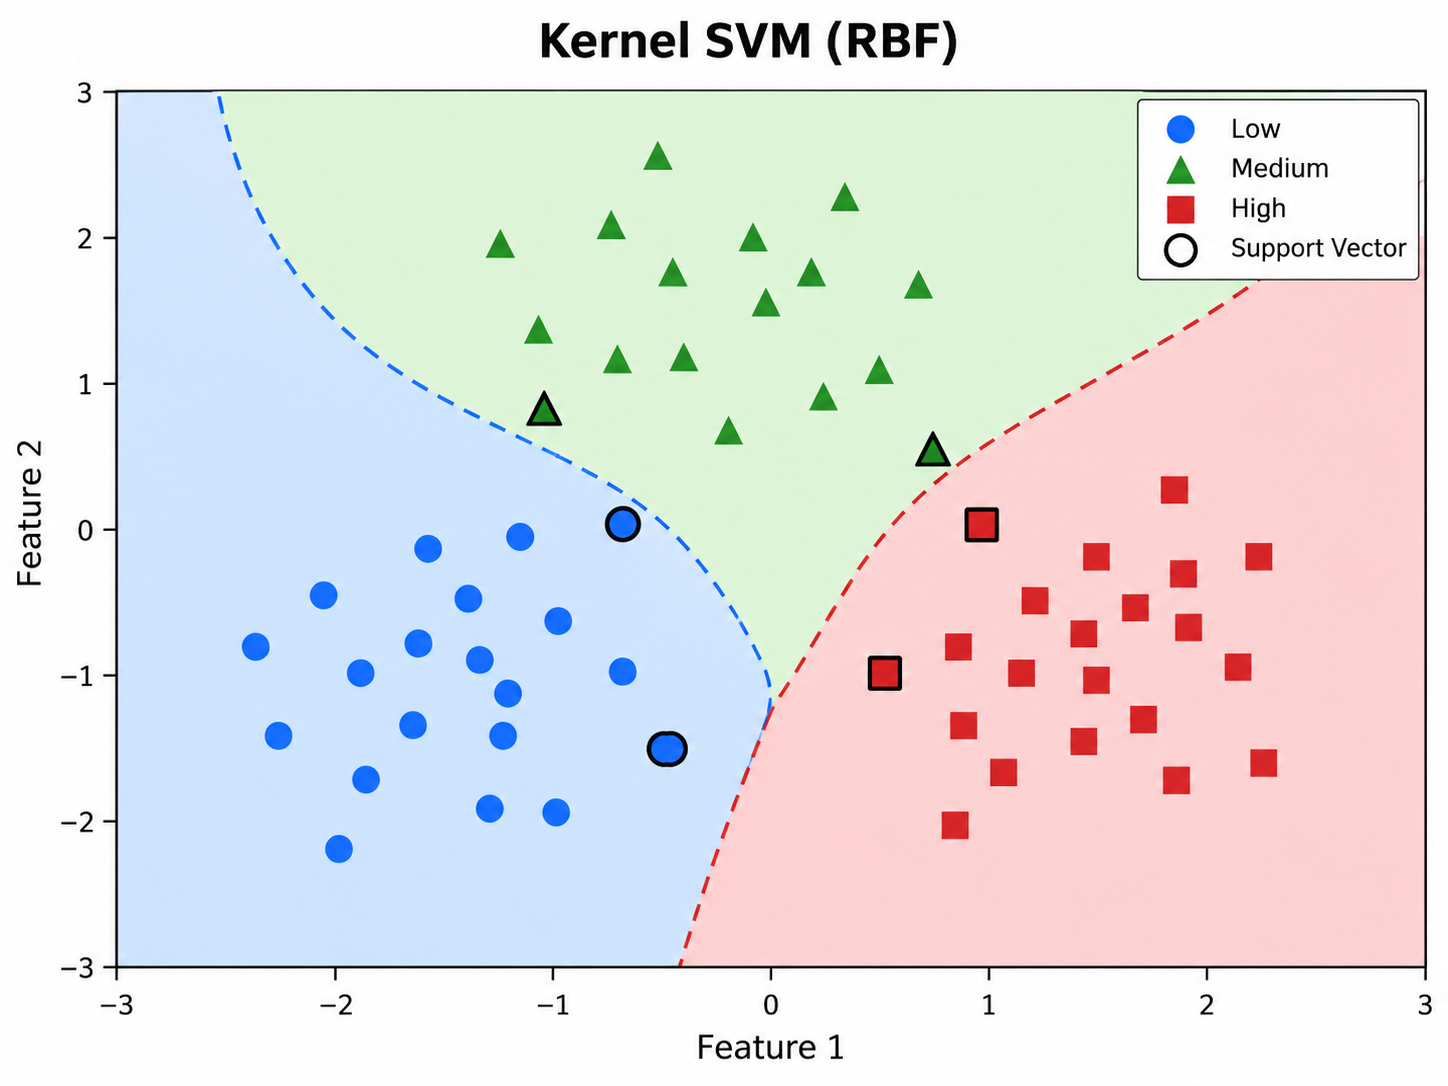
</div>

<p style="text-align:center; font-size:14px;">در SVM با Kernel، مرز بین کلاس‌ها می‌تواند خمیده و غیرخطی باشد.</p>

</div>

In [ ]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

# Create the RBF Kernel SVM classifier.
svm_rbf_model = SVC(
    kernel="rbf",
    C=1
)

##### C= 0.5

# Train the model.
svm_rbf_model.fit(X_train_scaled, y_train)

# Predict the validation data.
pred_svm_rbf = svm_rbf_model.predict(X_val_scaled)

# Calculate accuracy.
svm_rbf_accuracy = accuracy_score(
    y_val,
    pred_svm_rbf
)

print("Kernel SVM (RBF) Accuracy:", round(svm_rbf_accuracy, 3))

Kernel SVM (RBF) Accuracy: 0.58


<div dir="rtl" class="note-box">

### تفاوت ساده‌ی Linear و Kernel SVM

- **Linear SVM:** مرز تصمیم خطی است.
- **Kernel SVM:** مرز تصمیم می‌تواند غیرخطی باشد.

اگر داده تقریباً خطی جدا شود، Linear SVM ساده‌تر است.  
اگر الگو پیچیده‌تر باشد، Kernel SVM ممکن است بهتر عمل کند.

</div>

<div dir="rtl">

## ۹. Decision Tree Classification

Decision Tree با سؤال‌های متوالی داده را تقسیم می‌کند.

در انتهای هر Branch، یک Class پیش‌بینی می‌شود.

در این جلسه `max_depth` مهم‌ترین Hyperparameter ما است.

</div>

<div dir="rtl">

### Decision Tree Classification

<div style="text-align:center;">
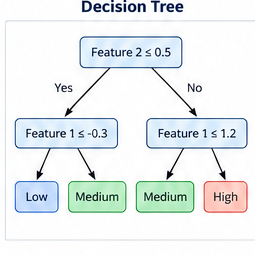
</div>

<p style="text-align:center; font-size:14px;">درخت با Splitهای متوالی در نهایت به Classهای مختلف می‌رسد.</p>

</div>

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

# Create the Decision Tree classifier.
tree_model = DecisionTreeClassifier(
    max_depth=3,
    random_state=0
)

# Train the model.
tree_model.fit(X_train, y_train)

# Predict the validation data.
pred_tree = tree_model.predict(X_val)

# Calculate accuracy.
tree_accuracy = accuracy_score(y_val, pred_tree)

print("Decision Tree Accuracy:", round(tree_accuracy, 3))

Decision Tree Accuracy: 0.534


<div dir="rtl">

## ۱۰. Random Forest Classification

Random Forest تعداد زیادی Decision Tree می‌سازد.

هر Tree یک رأی می‌دهد و در پایان مدل با ترکیب این رأی‌ها Class نهایی را تعیین می‌کند.

</div>

<div dir="rtl">

### Random Forest Classification

<div style="text-align:center;">
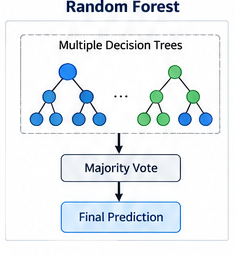
</div>

<p style="text-align:center; font-size:14px;">به‌جای اتکا به یک درخت، چندین Decision Tree با هم ترکیب می‌شوند.</p>

</div>

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# Create the Random Forest classifier.
forest_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=12,
    random_state=0
)

########     n_estimators=50, max_depth=6,


# Train the model.
forest_model.fit(X_train, y_train)

# Predict the validation data.
pred_forest = forest_model.predict(X_val)

# Calculate accuracy.
forest_accuracy = accuracy_score(y_val, pred_forest)

print("Random Forest Accuracy:", round(forest_accuracy, 3))

Random Forest Accuracy: 0.466


<div dir="rtl">

## ۱۱. معیارهای ارزیابی Classification

در این جلسه از چند Metric مهم استفاده می‌کنیم:

- **Accuracy**  
  چند درصد از کل Predictionها درست بوده‌اند؟

- **Precision**  
  از نمونه‌هایی که مدل یک Class را پیش‌بینی کرده، چند درصد واقعاً همان Class بوده‌اند؟

- **Recall**  
  از نمونه‌هایی که واقعاً متعلق به یک Class بوده‌اند، مدل چند درصد را پیدا کرده است؟

- **F1-score**  
  میانگینی هماهنگ از Precision و Recall

### چرا Macro Average؟

چون سه Class داریم، از `average="macro"` استفاده می‌کنیم تا هر Class وزن مساوی داشته باشد.

### مثال ساده با دو Class

فرض کنید فقط دو Class داریم: **Positive** و **Negative**.

در شکل زیر:

- **TP**: نمونه Positive بوده و مدل هم Positive گفته است.
- **FP**: نمونه Negative بوده ولی مدل Positive گفته است.
- **FN**: نمونه Positive بوده ولی مدل Negative گفته است.
- **TN**: نمونه Negative بوده و مدل هم Negative گفته است.

<div style="text-align:center; margin-top:12px; margin-bottom:12px;">
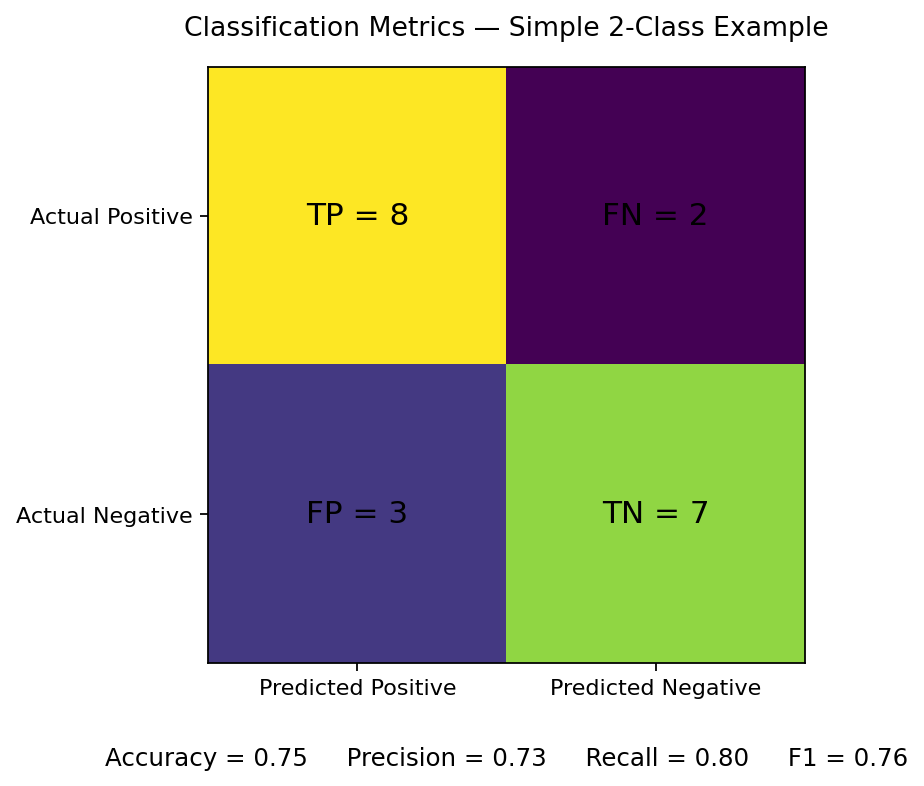
</div>

برای همین مثال:

- **Accuracy = 0.75** → از کل نمونه‌ها، 75٪ درست پیش‌بینی شده‌اند.
- **Precision = 0.73** → وقتی مدل Positive گفته، حدود 73٪ مواقع درست بوده است.
- **Recall = 0.80** → از تمام Positiveهای واقعی، 80٪ را پیدا کرده است.
- **F1 ≈ 0.76** → یک امتیاز ترکیبی از Precision و Recall.

</div>

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

# Evaluate Logistic Regression using several classification metrics.
accuracy = accuracy_score(y_val, pred_logistic)

precision = precision_score(
    y_val,
    pred_logistic,
    average="macro",
    zero_division=0
)

recall = recall_score(
    y_val,
    pred_logistic,
    average="macro",
    zero_division=0
)

f1 = f1_score(
    y_val,
    pred_logistic,
    average="macro",
    zero_division=0
)

print("Accuracy:", round(accuracy, 3))
print("Macro Precision:", round(precision, 3))
print("Macro Recall:", round(recall, 3))
print("Macro F1:", round(f1, 3))

Accuracy: 0.545
Macro Precision: 0.545
Macro Recall: 0.589
Macro F1: 0.555


<div dir="rtl">

## ۱۲. Confusion Matrix

Confusion Matrix نشان می‌دهد:

- Class واقعی چه بوده است؟
- مدل چه Classی را پیش‌بینی کرده است؟

اعداد روی قطر اصلی، Predictionهای درست هستند.

</div>

<div dir="rtl">

### نمونه‌ی Confusion Matrix

<div style="text-align:center; margin-top:12px; margin-bottom:12px;">
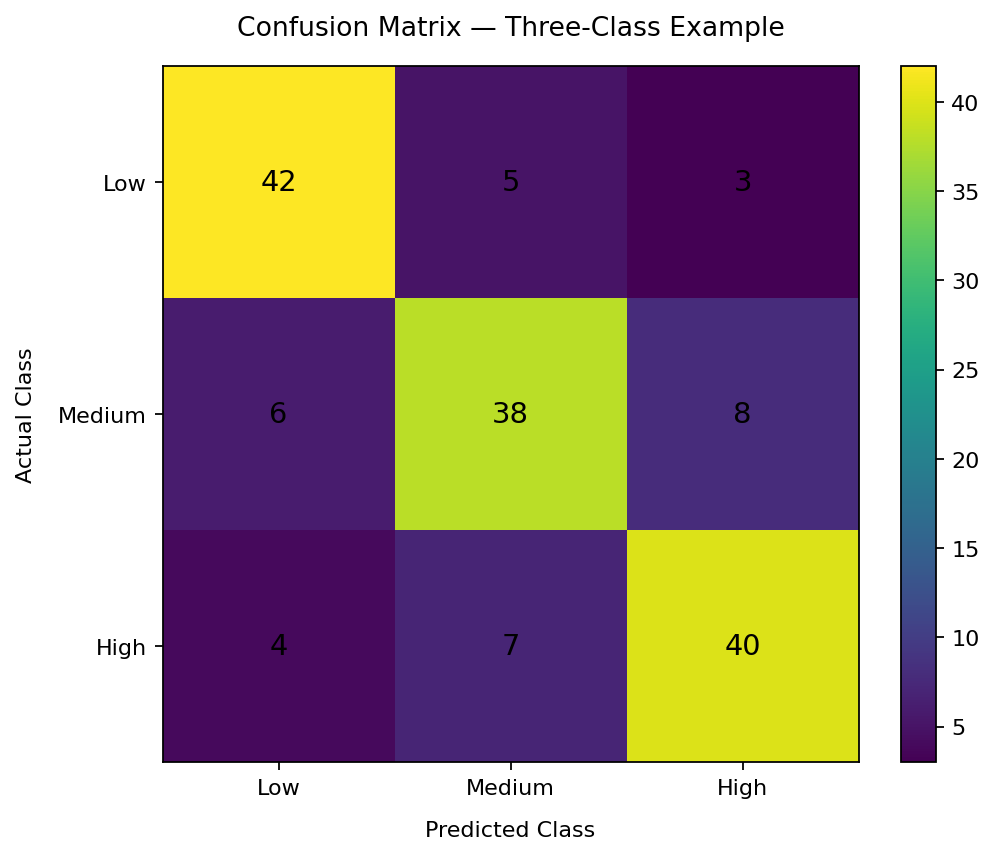
</div>

در این جدول:

- سطرها = **Class واقعی**
- ستون‌ها = **Class پیش‌بینی‌شده**
- اعداد روی قطر اصلی = **Predictionهای درست**
- اعداد خارج از قطر = **خطاهای مدل**

</div>

In [ ]:
import pandas as pd
from sklearn.metrics import confusion_matrix

class_names = ["Low", "Medium", "High"]

# Create the confusion matrix for Logistic Regression.
cm = confusion_matrix(
    y_val,
    pred_logistic,
    labels=class_names
)

cm_table = pd.DataFrame(
    cm,
    index=["Actual Low", "Actual Medium", "Actual High"],
    columns=["Predicted Low", "Predicted Medium", "Predicted High"]
)

print(cm_table)

               Predicted Low  Predicted Medium  Predicted High
Actual Low                15                 6               1
Actual Medium             15                15              11
Actual High                0                 7              18


In [ ]:
cm_table.sum().sum()

np.int64(88)

<div dir="rtl">

## ۱۳. Classification Report

این گزارش برای هر Class، مقدار Precision، Recall و F1-score را جداگانه نشان می‌دهد.

</div>

In [ ]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_val,
        pred_logistic,
        zero_division=0
    )
)

              precision    recall  f1-score   support

        High       0.60      0.72      0.65        25
         Low       0.50      0.68      0.58        22
      Medium       0.54      0.37      0.43        41

    accuracy                           0.55        88
   macro avg       0.55      0.59      0.56        88
weighted avg       0.55      0.55      0.53        88



<div dir="rtl">

## ۱۴. Validation Model Comparison

در این بخش همه‌ی مدل‌ها را روی یک Validation Set یکسان مقایسه می‌کنیم.

مدل‌های ما:

- Baseline
- Logistic Regression
- KNN
- Linear SVM
- Kernel SVM (RBF)
- Decision Tree
- Random Forest

</div>

In [ ]:
import pandas as pd
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

model_names = [
    "Baseline",
    "Logistic Regression",
    "KNN",
    "Linear SVM",
    "Kernel SVM (RBF)",
    "Decision Tree",
    "Random Forest"
]

predictions = [
    pred_baseline,
    pred_logistic,
    pred_knn,
    pred_svm_linear,
    pred_svm_rbf,
    pred_tree,
    pred_forest
]

results = []

for model_name, pred in zip(model_names, predictions):

    accuracy = accuracy_score(y_val, pred)

    precision = precision_score(
        y_val,
        pred,
        average="macro",
        zero_division=0
    )

    recall = recall_score(
        y_val,
        pred,
        average="macro",
        zero_division=0
    )

    f1 = f1_score(
        y_val,
        pred,
        average="macro",
        zero_division=0
    )

    results.append({
        "Model": model_name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1": f1
    })

validation_results = pd.DataFrame(results)
validation_results = validation_results.sort_values(
    "F1",
    ascending=False
)

print(validation_results.round(3))

                 Model  Accuracy  Precision  Recall     F1
6        Random Forest     0.602      0.601   0.630  0.611
4     Kernel SVM (RBF)     0.580      0.579   0.614  0.589
3           Linear SVM     0.568      0.568   0.613  0.578
2                  KNN     0.557      0.562   0.589  0.568
1  Logistic Regression     0.545      0.545   0.589  0.555
5        Decision Tree     0.534      0.538   0.587  0.546
0             Baseline     0.466      0.155   0.333  0.212


<div dir="rtl" class="note-box">

### نکته‌ی مهم

در Classification فقط به Accuracy اکتفا نکنید.

ممکن است مدل Accuracy خوبی داشته باشد، اما روی یکی از Classها ضعیف عمل کند.  
به همین دلیل Precision، Recall، F1 و Confusion Matrix نیز مهم هستند.

</div>

<div dir="rtl">

## ۱۵. Final Test Comparison

تا اینجا از Test Set برای انتخاب مدل یا تنظیم Hyperparameterها استفاده نکرده‌ایم.

اکنون همه‌ی مدل‌ها با همان تنظیمات ثابت یک‌بار روی Test Set بررسی می‌شوند.

بعد از مشاهده‌ی Test Results دیگر Hyperparameterها را تغییر نمی‌دهیم.

</div>

In [ ]:
# Prepare scaled test data for models that require scaling.
X_test_scaled = scaler.transform(X_test)

# Generate predictions for the test set.
pred_test_baseline = baseline.predict(X_test)
pred_test_logistic = logistic_model.predict(X_test_scaled)
pred_test_knn = knn_model.predict(X_test_scaled)
pred_test_svm_linear = svm_linear_model.predict(X_test_scaled)
pred_test_svm_rbf = svm_rbf_model.predict(X_test_scaled)
pred_test_tree = tree_model.predict(X_test)
pred_test_forest = forest_model.predict(X_test)

In [ ]:
import pandas as pd
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

test_model_names = [
    "Baseline",
    "Logistic Regression",
    "KNN",
    "Linear SVM",
    "Kernel SVM (RBF)",
    "Decision Tree",
    "Random Forest"
]

test_predictions = [
    pred_test_baseline,
    pred_test_logistic,
    pred_test_knn,
    pred_test_svm_linear,
    pred_test_svm_rbf,
    pred_test_tree,
    pred_test_forest
]

test_results = []

for model_name, pred in zip(test_model_names, test_predictions):

    test_results.append({
        "Model": model_name,
        "Accuracy": accuracy_score(y_test, pred),
        "Precision": precision_score(
            y_test,
            pred,
            average="macro",
            zero_division=0
        ),
        "Recall": recall_score(
            y_test,
            pred,
            average="macro",
            zero_division=0
        ),
        "F1": f1_score(
            y_test,
            pred,
            average="macro",
            zero_division=0
        )
    })

test_results = pd.DataFrame(test_results)
test_results = test_results.sort_values("F1", ascending=False)

print(test_results.round(3))

                 Model  Accuracy  Precision  Recall     F1
6        Random Forest     0.562      0.563   0.560  0.559
1  Logistic Regression     0.539      0.528   0.540  0.533
4     Kernel SVM (RBF)     0.539      0.528   0.540  0.532
2                  KNN     0.517      0.513   0.531  0.517
3           Linear SVM     0.517      0.506   0.516  0.510
5        Decision Tree     0.506      0.514   0.513  0.508
0             Baseline     0.472      0.157   0.333  0.214


<div dir="rtl">

## ۱۶. Final Confusion Matrix Example

در اینجا Confusion Matrix مربوط به **Kernel SVM (RBF)** را روی Test Set بررسی می‌کنیم.

</div>

In [ ]:
import pandas as pd
from sklearn.metrics import confusion_matrix

class_names = ["Low", "Medium", "High"]

cm_test = confusion_matrix(
    y_test,
    pred_test_svm_rbf,
    labels=class_names
)

#pred_test_forest

cm_test_table = pd.DataFrame(
    cm_test,
    index=["Actual Low", "Actual Medium", "Actual High"],
    columns=["Predicted Low", "Predicted Medium", "Predicted High"]
)

print(cm_test_table)

               Predicted Low  Predicted Medium  Predicted High
Actual Low                12                 6               3
Actual Medium             13                24               5
Actual High                0                12              14


<div dir="rtl" style="
    font-family: Tahoma, Arial, 'DejaVu Sans', sans-serif;
    font-size: 16px;
    line-height: 2;
    text-align: right;
">

<h2>۱۷. Quiz کوتاه</h2>

<h3>سؤال ۱</h3>
<p>
<bdi dir="ltr">Target</bdi>
در
<bdi dir="ltr">Classification</bdi>
معمولاً چه شکلی است؟
</p>

<p>
A. یک عدد پیوسته<br>
B. یک <bdi dir="ltr">Class</bdi> یا <bdi dir="ltr">Category</bdi><br>
C. فقط درصد
</p>

<h3>سؤال ۲</h3>
<p>
کدام مدل به
<bdi dir="ltr">Scale</bdi>
ویژگی‌ها حساس است؟
</p>

<p>
A. <bdi dir="ltr">KNN</bdi><br>
B. <bdi dir="ltr">SVM</bdi><br>
C. هر دو
</p>

<h3>سؤال ۳</h3>
<p>
تفاوت اصلی
<bdi dir="ltr">Linear SVM</bdi>
و
<bdi dir="ltr">Kernel SVM</bdi>
چیست؟
</p>

<p>
A. <bdi dir="ltr">Linear SVM</bdi> فقط برای <bdi dir="ltr">Regression</bdi> است.<br>

B. <bdi dir="ltr">Linear SVM</bdi> مرز خطی دارد و
<bdi dir="ltr">Kernel SVM</bdi>
می‌تواند مرز غیرخطی بسازد.<br>

C. <bdi dir="ltr">Kernel SVM</bdi>
اصلاً از
<bdi dir="ltr">Support Vector</bdi>
استفاده نمی‌کند.
</p>

<h3>سؤال ۴</h3>
<p>
چرا از
<bdi dir="ltr">Macro F1</bdi>
استفاده می‌کنیم؟
</p>

<p>
A. چون هر <bdi dir="ltr">Class</bdi> وزن مساوی دارد.<br>
B. چون فقط <bdi dir="ltr">Accuracy</bdi> مهم است.<br>
C. چون فقط برای <bdi dir="ltr">Tree</bdi>ها استفاده می‌شود.
</p>

<h3>سؤال ۵</h3>
<p>
در
<bdi dir="ltr">Confusion Matrix</bdi>،
اعداد روی قطر اصلی معمولاً چه چیزی را نشان می‌دهند؟
</p>

<p>
A. <bdi dir="ltr">Prediction</bdi>های درست<br>
B. <bdi dir="ltr">Hyperparameter</bdi>ها<br>
C. تعداد <bdi dir="ltr">Feature</bdi>ها
</p>

<h3>سؤال ۶</h3>
<p>
بعد از دیدن
<bdi dir="ltr">Test Results</bdi>
آیا باید
<bdi dir="ltr">Hyperparameter</bdi>ها
را دوباره تغییر دهیم؟
</p>

<p>
A. بله<br>
B. خیر
</p>

</div>

<div dir="rtl" style="
    font-family: Tahoma, Arial, 'DejaVu Sans', sans-serif;
    font-size: 16px;
    line-height: 2;
    text-align: right;
">

<details>

<summary><b>پاسخ Quiz — برای مشاهده کلیک کنید</b></summary>

<p>
<b>۱. B —</b>
<bdi dir="ltr">Class</bdi>
یا
<bdi dir="ltr">Category</bdi>
</p>

<p>
<b>۲. C —</b>
هر دو
</p>

<p>
<b>۳. B —</b>
<bdi dir="ltr">Linear SVM</bdi>
مرز خطی دارد و
<bdi dir="ltr">Kernel SVM</bdi>
می‌تواند مرز غیرخطی بسازد.
</p>

<p>
<b>۴. A —</b>
هر
<bdi dir="ltr">Class</bdi>
وزن مساوی دارد.
</p>

<p>
<b>۵. A —</b>
<bdi dir="ltr">Prediction</bdi>های درست
</p>

<p>
<b>۶. خیر —</b>
بعد از دیدن
<bdi dir="ltr">Test Results</bdi>
نباید
<bdi dir="ltr">Hyperparameter</bdi>ها
را دوباره تغییر دهیم.
</p>

</details>

</div>

<div dir="rtl">

## ۱۸. تمرین ۱ — KNN

مقادیر زیر را برای `n_neighbors` امتحان کنید:

- `5`
- `8`
- `12`
- `15`

برای هر مدل، Validation Accuracy و Macro F1 را حساب کنید.

</div>

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, f1_score

# Change the value of K.
k = 5

model = KNeighborsClassifier(
    n_neighbors=k
)

model.fit(X_train_scaled, y_train)

pred = model.predict(X_val_scaled)

accuracy = accuracy_score(y_val, pred)

f1 = f1_score(
    y_val,
    pred,
    average="macro"
)

print("K =", k)
print("Accuracy =", round(accuracy, 3))
print("Macro F1 =", round(f1, 3))

<div dir="rtl">

## ۱۹. تمرین ۲ — SVM

یک بار **Linear SVM** و یک بار **Kernel SVM (RBF)** را اجرا کنید و Validation Macro F1 آن‌ها را مقایسه کنید.

### سؤال

آیا Kernel SVM در این Dataset از Linear SVM بهتر عمل می‌کند؟

</div>

In [ ]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, f1_score

# Change the kernel type to "linear" or "rbf".
kernel_type = "linear"

model = SVC(
    kernel=kernel_type,
    C=1,
    gamma="scale"
)

model.fit(X_train_scaled, y_train)

pred = model.predict(X_val_scaled)

accuracy = accuracy_score(y_val, pred)

f1 = f1_score(
    y_val,
    pred,
    average="macro"
)

print("Kernel =", kernel_type)
print("Accuracy =", round(accuracy, 3))
print("Macro F1 =", round(f1, 3))

<div dir="rtl">

# جمع‌بندی جلسه ۵

امروز همان Diabetes Dataset را به یک مسئله‌ی سه‌کلاسه تبدیل کردیم و چند خانواده‌ی مهم از مدل‌های Classification را دیدیم:

- **Logistic Regression**
- **KNN**
- **Linear SVM**
- **Kernel SVM**
- **Decision Tree**
- **Random Forest**

همچنین دیدیم که برای ارزیابی Classification فقط Accuracy کافی نیست و باید Precision، Recall، F1 و Confusion Matrix را هم بررسی کنیم.

> پیام اصلی جلسه:  
> **در Classification هم مدل مهم است، هم نوع Metric.**

</div>